---
title: "CRISP-DM Python implementation"
format: 
  html:
    code-fold: show
    toc: true
---

[<i class="bi bi-arrow-left"></i> Back to Project Summary](mining_index.qmd){.btn .btn-outline-secondary .btn-sm role="button"}

<a href="#top" id="back-to-top" 
   style="position: fixed; bottom: 20px; right: 20px; 
          padding: 8px 15px; background: rgba(52, 58, 64, 0.8); 
          color: white; border-radius: 4px; text-align: center; 
          font-size: 13px; font-weight: bold; z-index: 1000; 
          text-decoration: none; transition: 0.3s; border: 1px solid #495057;">
  BACK TO TOP ↑
</a>

---

## Imports

In [61]:
# importing libraries
!pip install ucimlrepo imbalanced-learn xgboost -q

import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc
from imblearn.over_sampling import SMOTE
import xgboost as xgb
from ucimlrepo import fetch_ucirepo

import warnings
warnings.filterwarnings('ignore')

## Data Loading

In [62]:
# data loading and structure
adult = fetch_ucirepo(id=2)
df = pd.concat([adult.data.features, adult.data.targets], axis=1)

print(df.info())
print('---------------------------------------------------------------------------------')
print("\n", df.describe())
print('---------------------------------------------------------------------------------')
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             48842 non-null  int64 
 1   workclass       47879 non-null  object
 2   fnlwgt          48842 non-null  int64 
 3   education       48842 non-null  object
 4   education-num   48842 non-null  int64 
 5   marital-status  48842 non-null  object
 6   occupation      47876 non-null  object
 7   relationship    48842 non-null  object
 8   race            48842 non-null  object
 9   sex             48842 non-null  object
 10  capital-gain    48842 non-null  int64 
 11  capital-loss    48842 non-null  int64 
 12  hours-per-week  48842 non-null  int64 
 13  native-country  48568 non-null  object
 14  income          48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB
None
---------------------------------------------------------------------------------

     

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


## Data Preprocessing

In [63]:
# data quality check
print("Missing values per column:")
print(df.isnull().sum())
print('---------------------------------')

print("\n'?' symbols per column:")
for col in df.select_dtypes(include=['object']).columns:
    question_marks = (df[col] == '?').sum()
    if question_marks > 0:
        print(f"{col}: {question_marks} ({question_marks/len(df)*100:.1f}%)")

print('\n---------------------------------')

print(df['income'].value_counts())
df['income'] = df['income'].str.replace('.', '', regex=False)
print("\nAfter cleaning target variable")
print(df['income'].value_counts())

Missing values per column:
age                 0
workclass         963
fnlwgt              0
education           0
education-num       0
marital-status      0
occupation        966
relationship        0
race                0
sex                 0
capital-gain        0
capital-loss        0
hours-per-week      0
native-country    274
income              0
dtype: int64
---------------------------------

'?' symbols per column:
workclass: 1836 (3.8%)
occupation: 1843 (3.8%)
native-country: 583 (1.2%)

---------------------------------
income
<=50K     24720
<=50K.    12435
>50K       7841
>50K.      3846
Name: count, dtype: int64

After cleaning target variable
income
<=50K    37155
>50K     11687
Name: count, dtype: int64


In [64]:
# data cleaning
df.replace('?', np.nan, inplace=True)
for col in df.select_dtypes('object'): df[col].fillna('Unknown', inplace=True)
for col in df.select_dtypes('number'): df[col].fillna(df[col].median(), inplace=True)
df['income'] = LabelEncoder().fit_transform(df['income'])

print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
income            0
dtype: int64


In [65]:
# onehot encoding for linear models
category_cols = [col for col in df.select_dtypes('object').columns if col != 'income']
df_onehot = pd.get_dummies(df, columns=category_cols, drop_first=True)
X_onehot, y = df_onehot.drop('income', axis=1), df_onehot['income']

# label encoding for tree models
df_label = df.copy()
for col in category_cols: df_label[col] = LabelEncoder().fit_transform(df_label[col])
X_label = df_label.drop('income', axis=1)

In [66]:
# train test split
X1_train, X1_test, y1_train, y_test = train_test_split(X_onehot, y, test_size=0.2, stratify=y, random_state=42)

X2_train, X2_test, y2_train, y_test = train_test_split(X_label, y, test_size=0.2, stratify=y, random_state=42)

In [67]:
# standard scaling (only linear model)
scaler = StandardScaler()
X1_train = scaler.fit_transform(X1_train)
X1_test = scaler.transform(X1_test)

# SMOTE
X1_train, y1_train = SMOTE(random_state=42).fit_resample(X1_train, y1_train)
X2_train, y2_train = SMOTE(random_state=42).fit_resample(X2_train, y2_train)

## Model Development

In [68]:
# model training
models = {
    'Logistic Regression': (LogisticRegression(max_iter=1000), X1_train, y1_train, X1_test),
    'Naive Bayes': (GaussianNB(), X1_train, y1_train, X1_test),
    'Decision Tree': (DecisionTreeClassifier(max_depth=15), X2_train, y2_train, X2_test),
    'Random Forest': (RandomForestClassifier(n_estimators=100, max_depth=15), X2_train, y2_train, X2_test),
    'XGBoost': (xgb.XGBClassifier(eval_metric='logloss'), X2_train, y2_train, X2_test)
}

results, models_trained = {}, {}

for name, (model, Xtr, ytr, Xte) in models.items():
    model.fit(Xtr, ytr)
    pred, prob = model.predict(Xte), model.predict_proba(Xte)[:,1]
    results[name] = {
        'Accuracy': accuracy_score(y_test, pred),
        'Precision': precision_score(y_test, pred),
        'Recall': recall_score(y_test, pred),
        'F1-Score': f1_score(y_test, pred),
        'pred': pred, 'prob': prob
    }
    models_trained[name] = model

df_res = pd.DataFrame(results).T.sort_values('Accuracy', ascending=False).reset_index().rename(columns={'index': 'Model'})

## Results

In [69]:
print(df_res[['Model', 'Accuracy', 'Precision', 'Recall', 'F1-Score']])

                 Model  Accuracy Precision    Recall  F1-Score
0              XGBoost  0.868973  0.729004  0.720274  0.724613
1        Random Forest  0.847374  0.662697   0.73781  0.698239
2        Decision Tree  0.834681  0.638985  0.710864  0.673011
3  Logistic Regression  0.809704  0.570214  0.831908  0.676639
4          Naive Bayes  0.536288  0.335039  0.952096  0.495658


# Visualisations

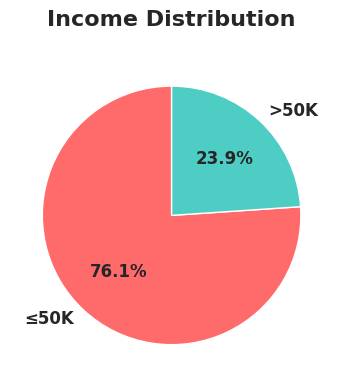

In [70]:
# visualisations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 11

colors_models = plt.cm.Set3(np.linspace(0, 1, len(df_res['Model'])))
colors_pie = ['#ff6b6b', '#4ecdc4']
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

# income distribution
plt.figure(figsize=(4, 4))
income_counts = df['income'].value_counts()
income_labels = ['≤50K', '>50K'] if df['income'].dtype == 'object' else ['≤50K', '>50K']
plt.pie(income_counts.values, labels=income_labels, autopct='%1.1f%%',
        colors=colors_pie, startangle=90, textprops={'fontsize': 12, 'fontweight': 'bold'})
plt.title('Income Distribution', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

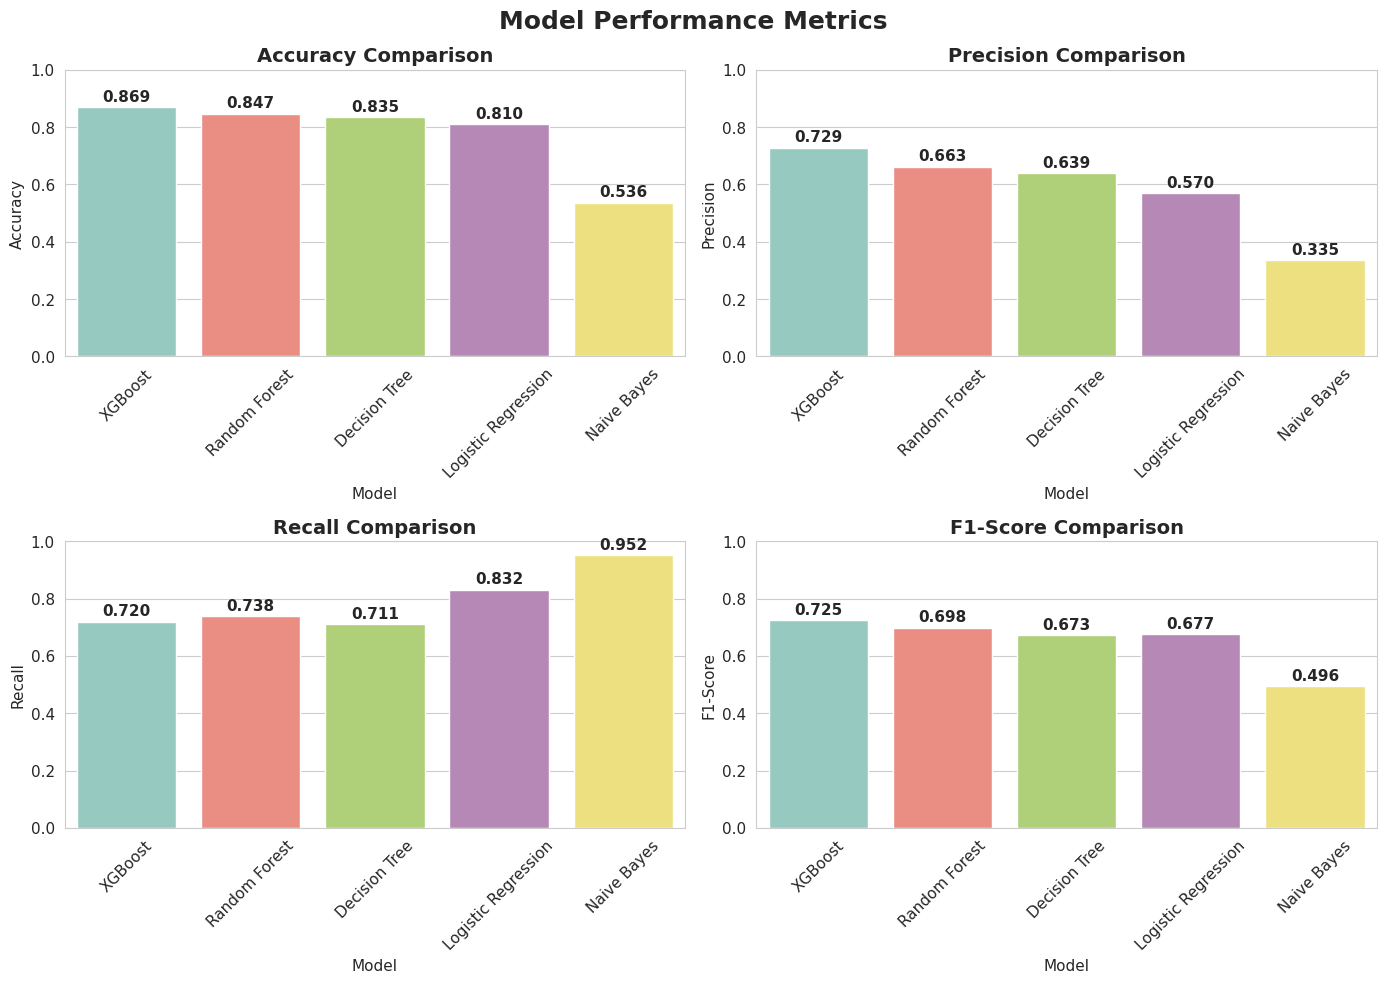

In [71]:
# results bar graphs
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, metric in enumerate(metrics):
    sns.barplot(data=df_res, x='Model', y=metric, palette=colors_models, ax=axes[i])
    axes[i].set_title(f'{metric} Comparison', fontweight='bold', fontsize=14)
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].set_ylim(0, 1)

    for j, bar in enumerate(axes[i].patches):
        height = bar.get_height()
        axes[i].text(bar.get_x() + bar.get_width()/2., height + 0.01,
                    f'{height:.3f}', ha='center', va='bottom', fontweight='bold')

plt.suptitle('Model Performance Metrics', fontsize=18, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

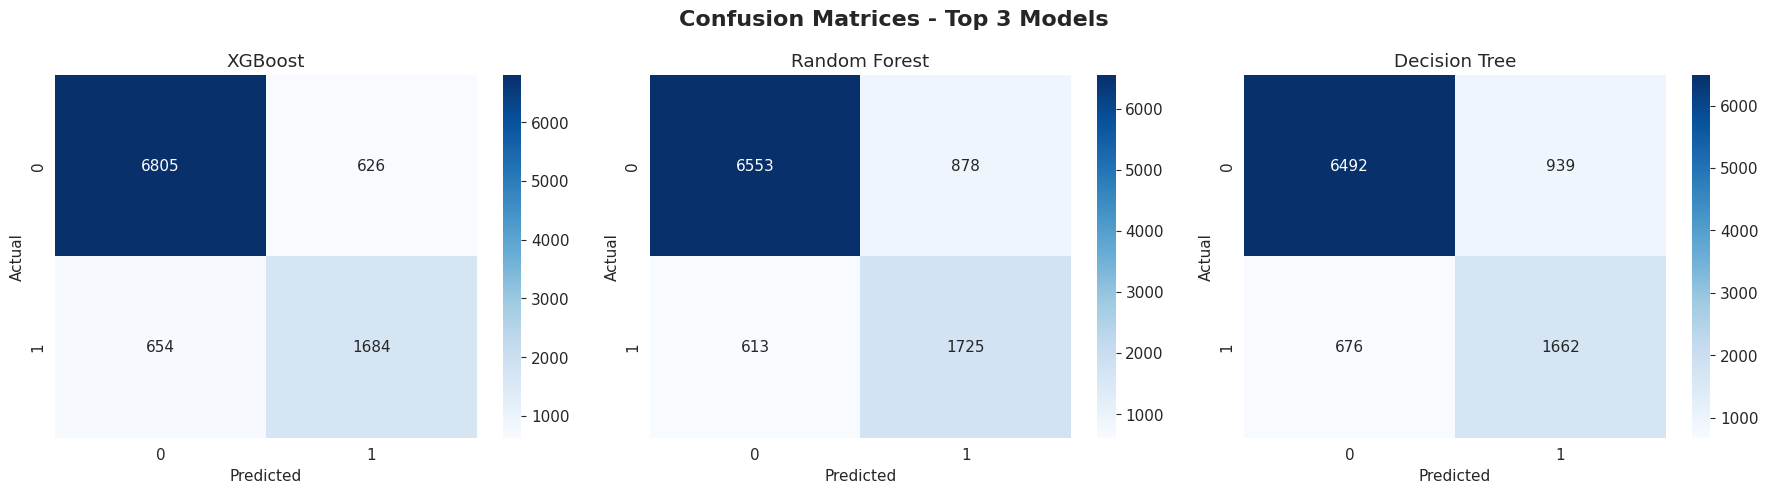

In [72]:
# confusion matrix
fig, axes = plt.subplots(1, 3, figsize=(18,5))
fig.suptitle('Confusion Matrices - Top 3 Models', fontsize=16, fontweight='bold')
for i, name in enumerate(df_res['Model'][:3]):
    cm = confusion_matrix(y_test, results[name]['pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i])
    axes[i].set_title(name)
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')
plt.tight_layout()
plt.show()

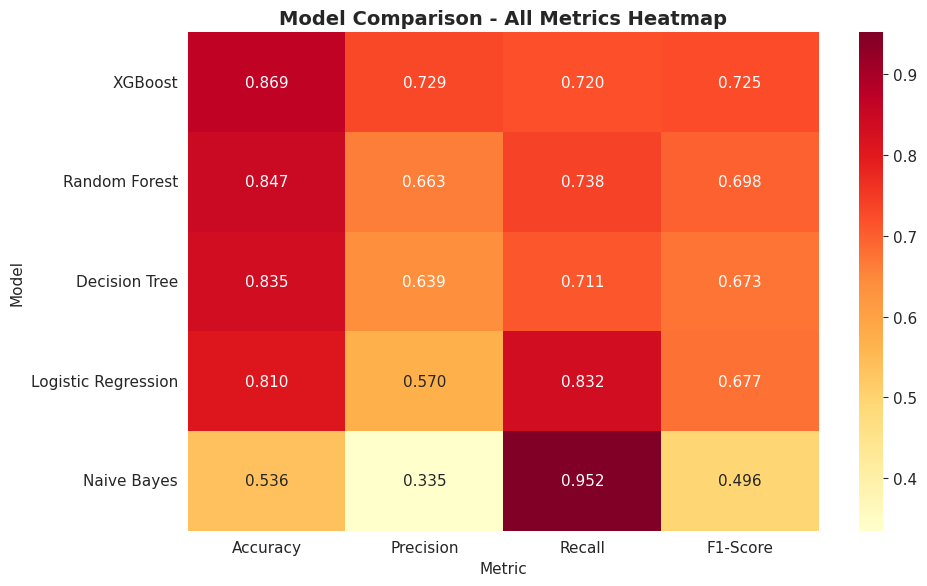

In [73]:
# metrics heat map
plt.figure(figsize=(10, 6))
heatmap_data = df_res[metrics].astype(float).values

sns.heatmap(heatmap_data,
            annot=True,
            fmt=".3f",
            cmap='YlOrRd',
            xticklabels=metrics,
            yticklabels=df_res['Model'],
            cbar=True)

plt.title("Model Comparison - All Metrics Heatmap", fontsize=14, fontweight='bold')
plt.xlabel("Metric")
plt.ylabel("Model")
plt.tight_layout()
plt.show()

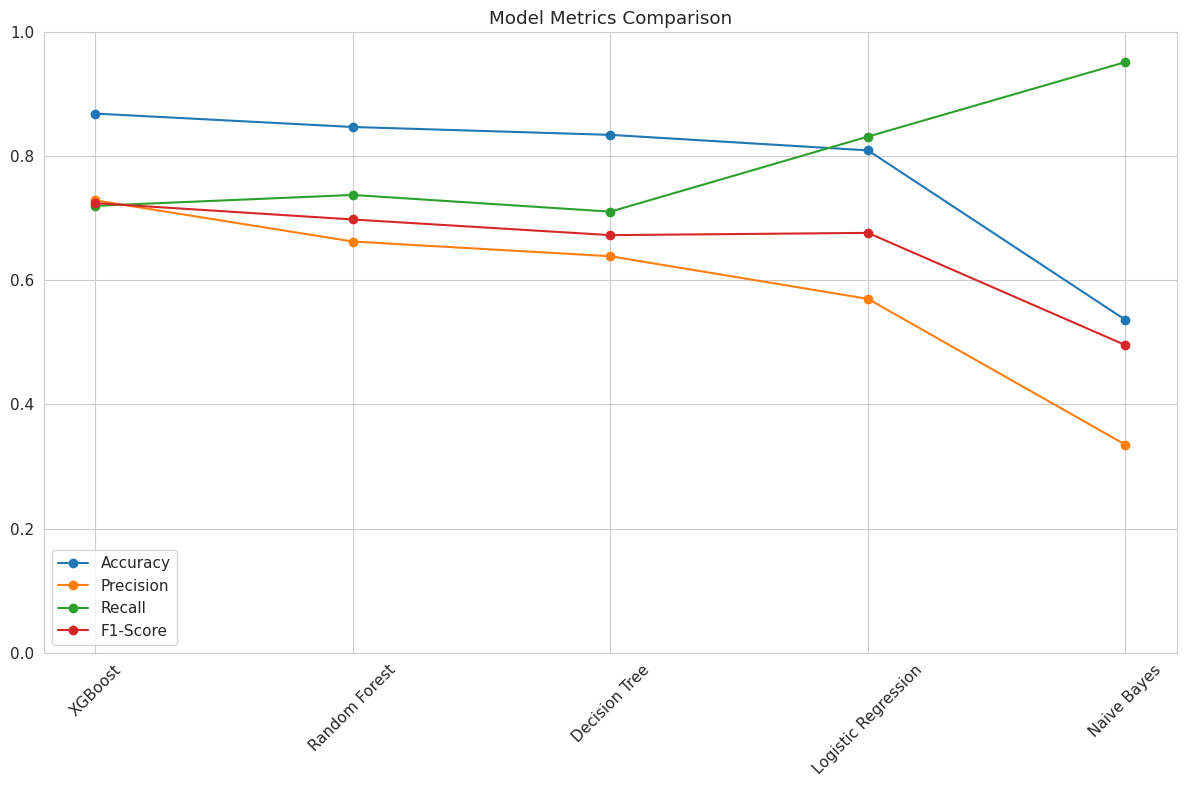

In [74]:
# metric line graph
plt.figure()
for metric in ['Accuracy', 'Precision', 'Recall', 'F1-Score']:
    plt.plot(df_res['Model'], df_res[metric], marker='o', label=metric)
plt.title('Model Metrics Comparison')
plt.legend()
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

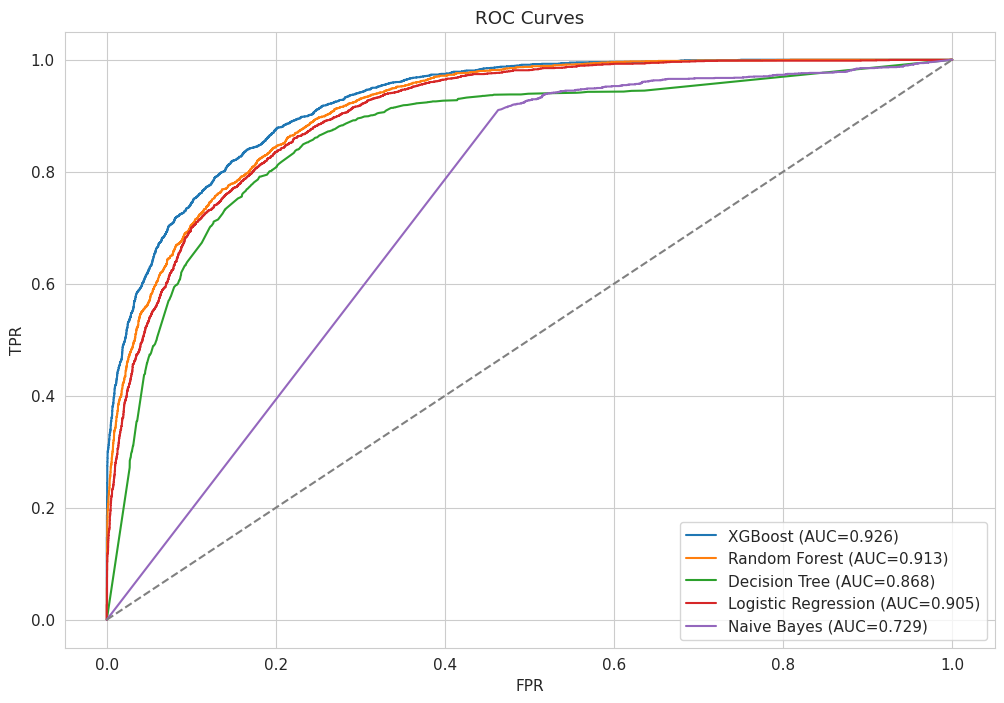

In [75]:
# roc-auc
plt.figure()
for name in df_res['Model']:
    fpr, tpr, _ = roc_curve(y_test, results[name]['prob'])
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc(fpr,tpr):.3f})')
plt.plot([0,1],[0,1],'--',color='gray')
plt.title('ROC Curves')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.legend()
plt.show()